# study_v2_gp — per-category GP vs LVGP (visualizations)

**Part 2** of the heteroscedastic mixed-variable BO study. Same problem and same 12-config ×
n_rep{3,5,10} × 30-seed sweep as the MATLAB **LVGP** study (`study_v2`), but the model is the
opposite choice: **one independent botorch GP per category** (no cross-category sharing).
LVGP's advantage is exactly that sharing, so this baseline isolates its value.

Plotting reuses **study_v2's `StudyResults`** (identical plots/metrics → true apples-to-apples
comparison) via a dual-format loader (`.npz` here, `.mat` for LVGP), plus `compare_studies()`
for the head-to-head overlays.

> **Kernel:** select **ml_gp_env** (botorch 0.14). Run `python run_sweep.py` first to populate
> `results/` (the cells below also work on a partial / toy sweep). Convention matches
> study_v2/analysis.ipynb: `%matplotlib inline` + bare `plot_*()` calls.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
sys.path.insert(0, os.path.abspath(".."))      # so `from utils import ...` works from notebooks/
%matplotlib inline

from utils import StudyResults, compare_studies, problem

gp   = StudyResults.load("../results")                 # this study (per-category GP, .npz)
lvgp = StudyResults.load("../../study_v2/results")     # the LVGP study (.mat), for the overlay
lv, x1 = problem.true_opt_location()
print(f"per-category GP: {len(gp.runs)} runs   |   LVGP: {len(lvgp.runs)} runs")
print(f"true global min = {problem.ground_truth_min():.4f}  at level {lv} (x2={problem.VAR_FCTR[lv-1]:g}), x1={x1:.3f}")

per-category GP: 1080 runs   |   LVGP: 1080 runs
true global min = 0.4651  at level 2 (x2=2), x1=3.181


In [2]:
# final-iteration summary per config × n_rep (true-regret is the headline metric)
gp.summary()

1080 runs | 12 configs | n_rep=[3, 5, 10] | seeds=30 | ground-truth min = 0.465


## Standard gallery — the same plots as the LVGP study
Every `plot_*` returns a Figure (rendered inline). `save_all_plots.py` writes the whole tree to
`plots/`. A representative selection (run time, points, convergence, regret) is shown below.

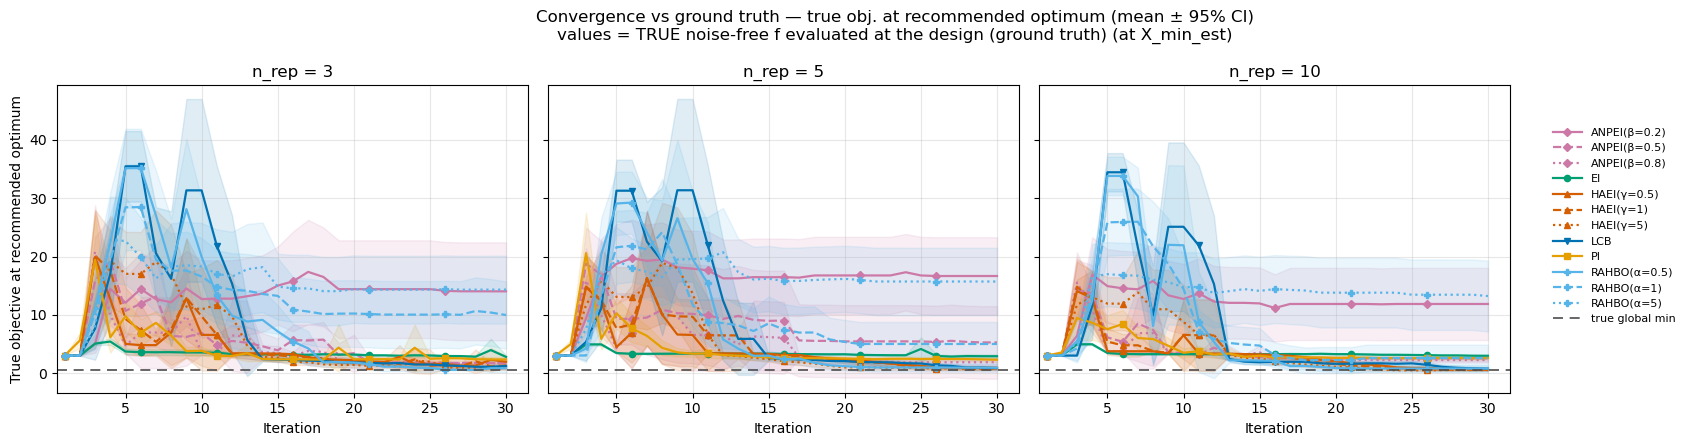

In [3]:
# convergence of TRUE regret at the recommended optimum (log scale)
gp.plot_convergence_true(log=False)

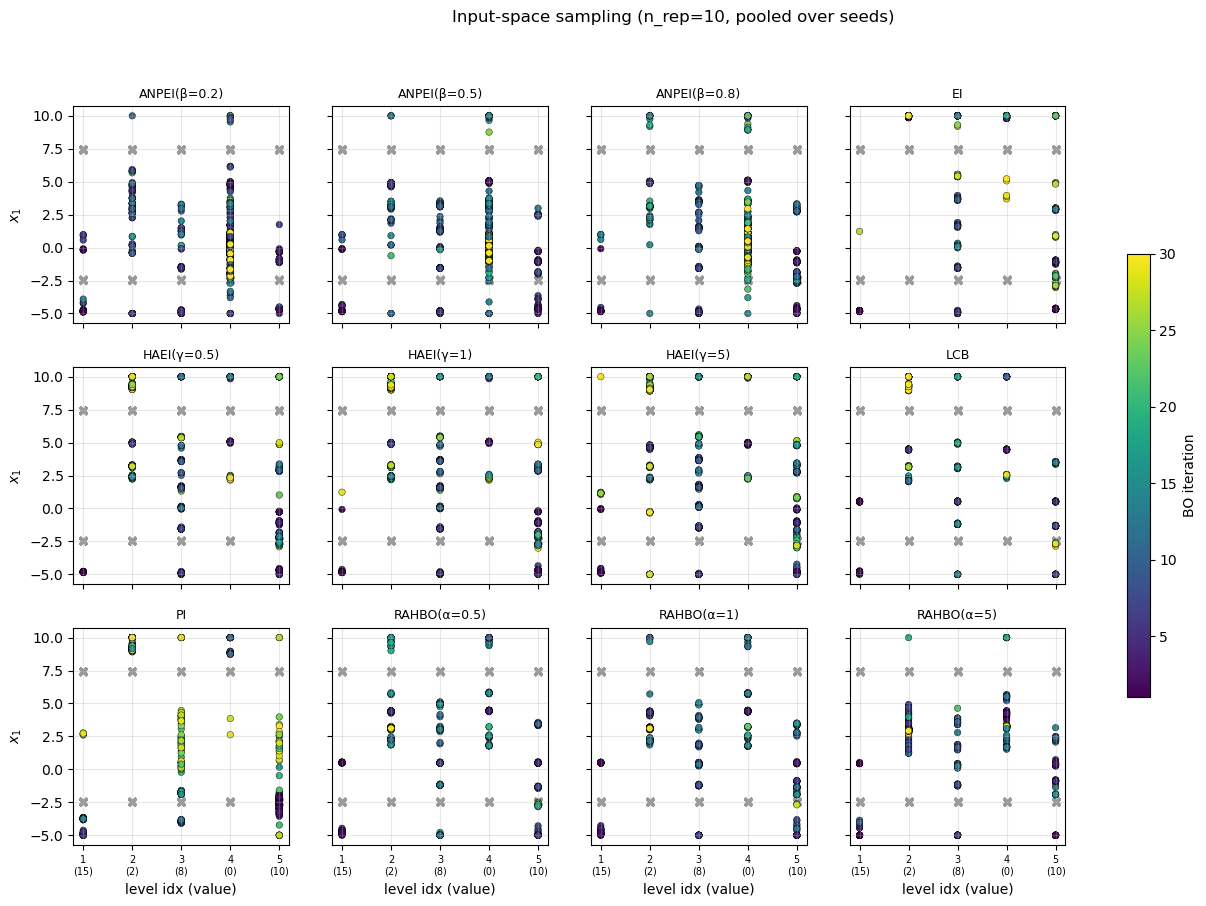

In [4]:
# input-space sampling: where BO placed points across the 5 categories (× = initial DOE)
gp.plot_input_space(n_rep=10)

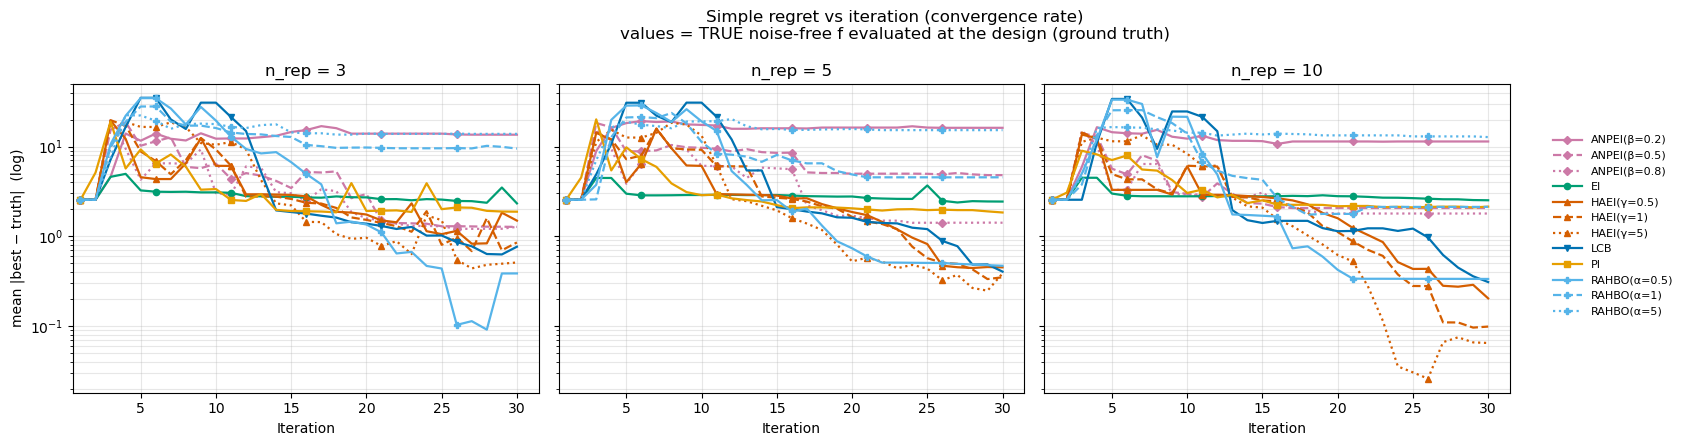

In [5]:
# simple (true) regret per acquisition
gp.plot_simple_regret(is_ground_truth=True)

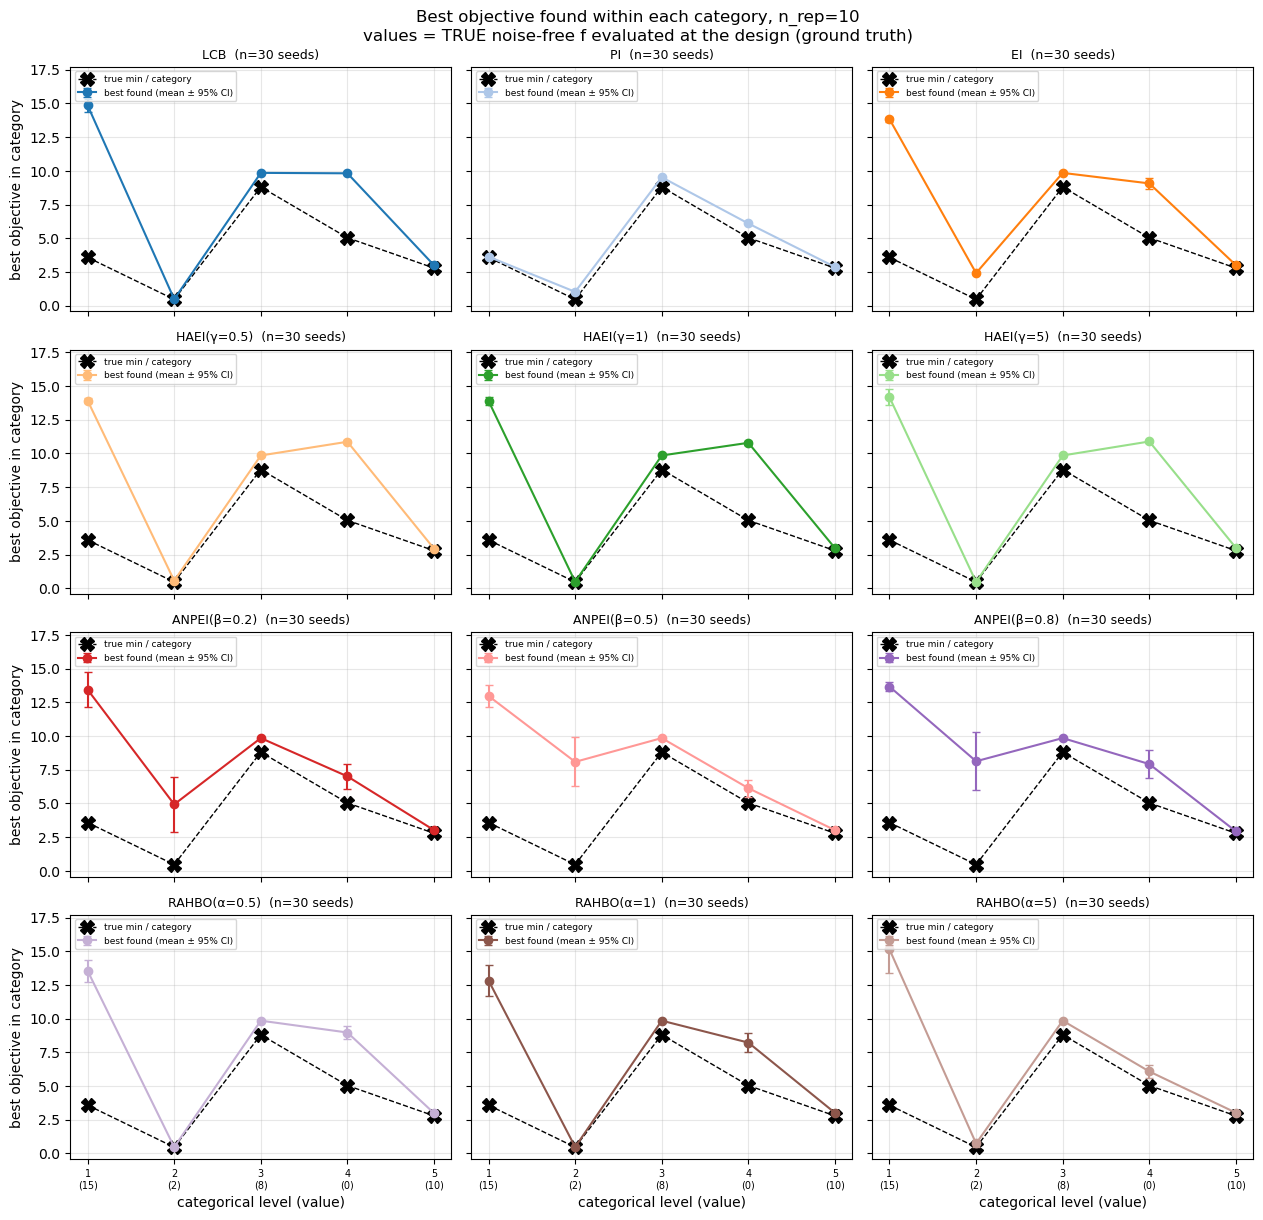

In [6]:
# best design found within each category
gp.plot_best_per_category(n_rep=10, is_ground_truth=True)

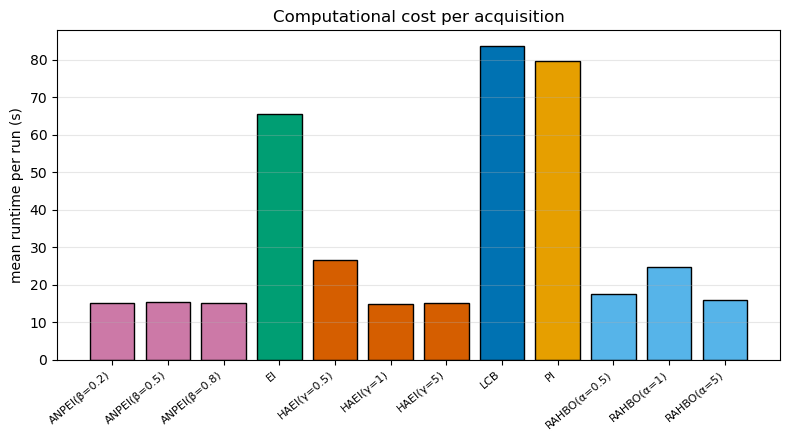

In [7]:
# wall-clock runtime per acquisition
gp.plot_runtime()

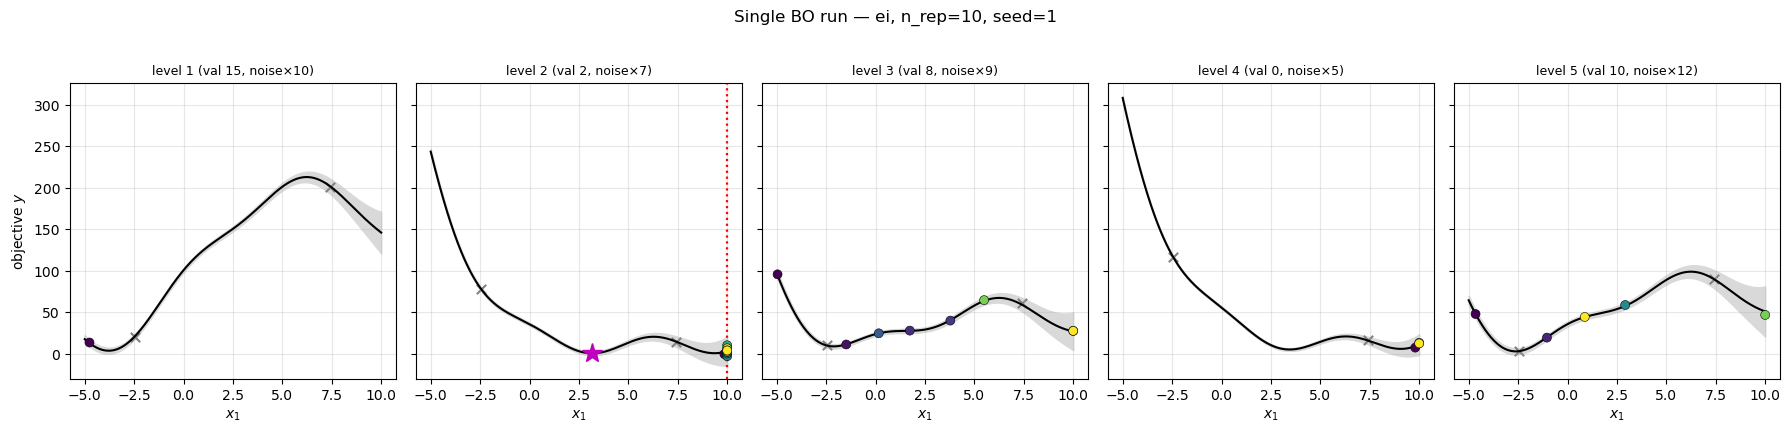

In [8]:
# one BO run, per-category slices (true f ± noise band + where BO sampled, coloured by iter)
gp.plot_single_run("ei/nrep10/seed01.npz")

## Head-to-head: per-category GP vs LVGP  (the Part-2 question)
`compare_studies` overlays both studies on the same axes — one subplot per acquisition,
mean ± s.e. over seeds. Expect **LVGP ≤ per-category GP** in true regret on the harder configs,
the signature of cross-category sharing.

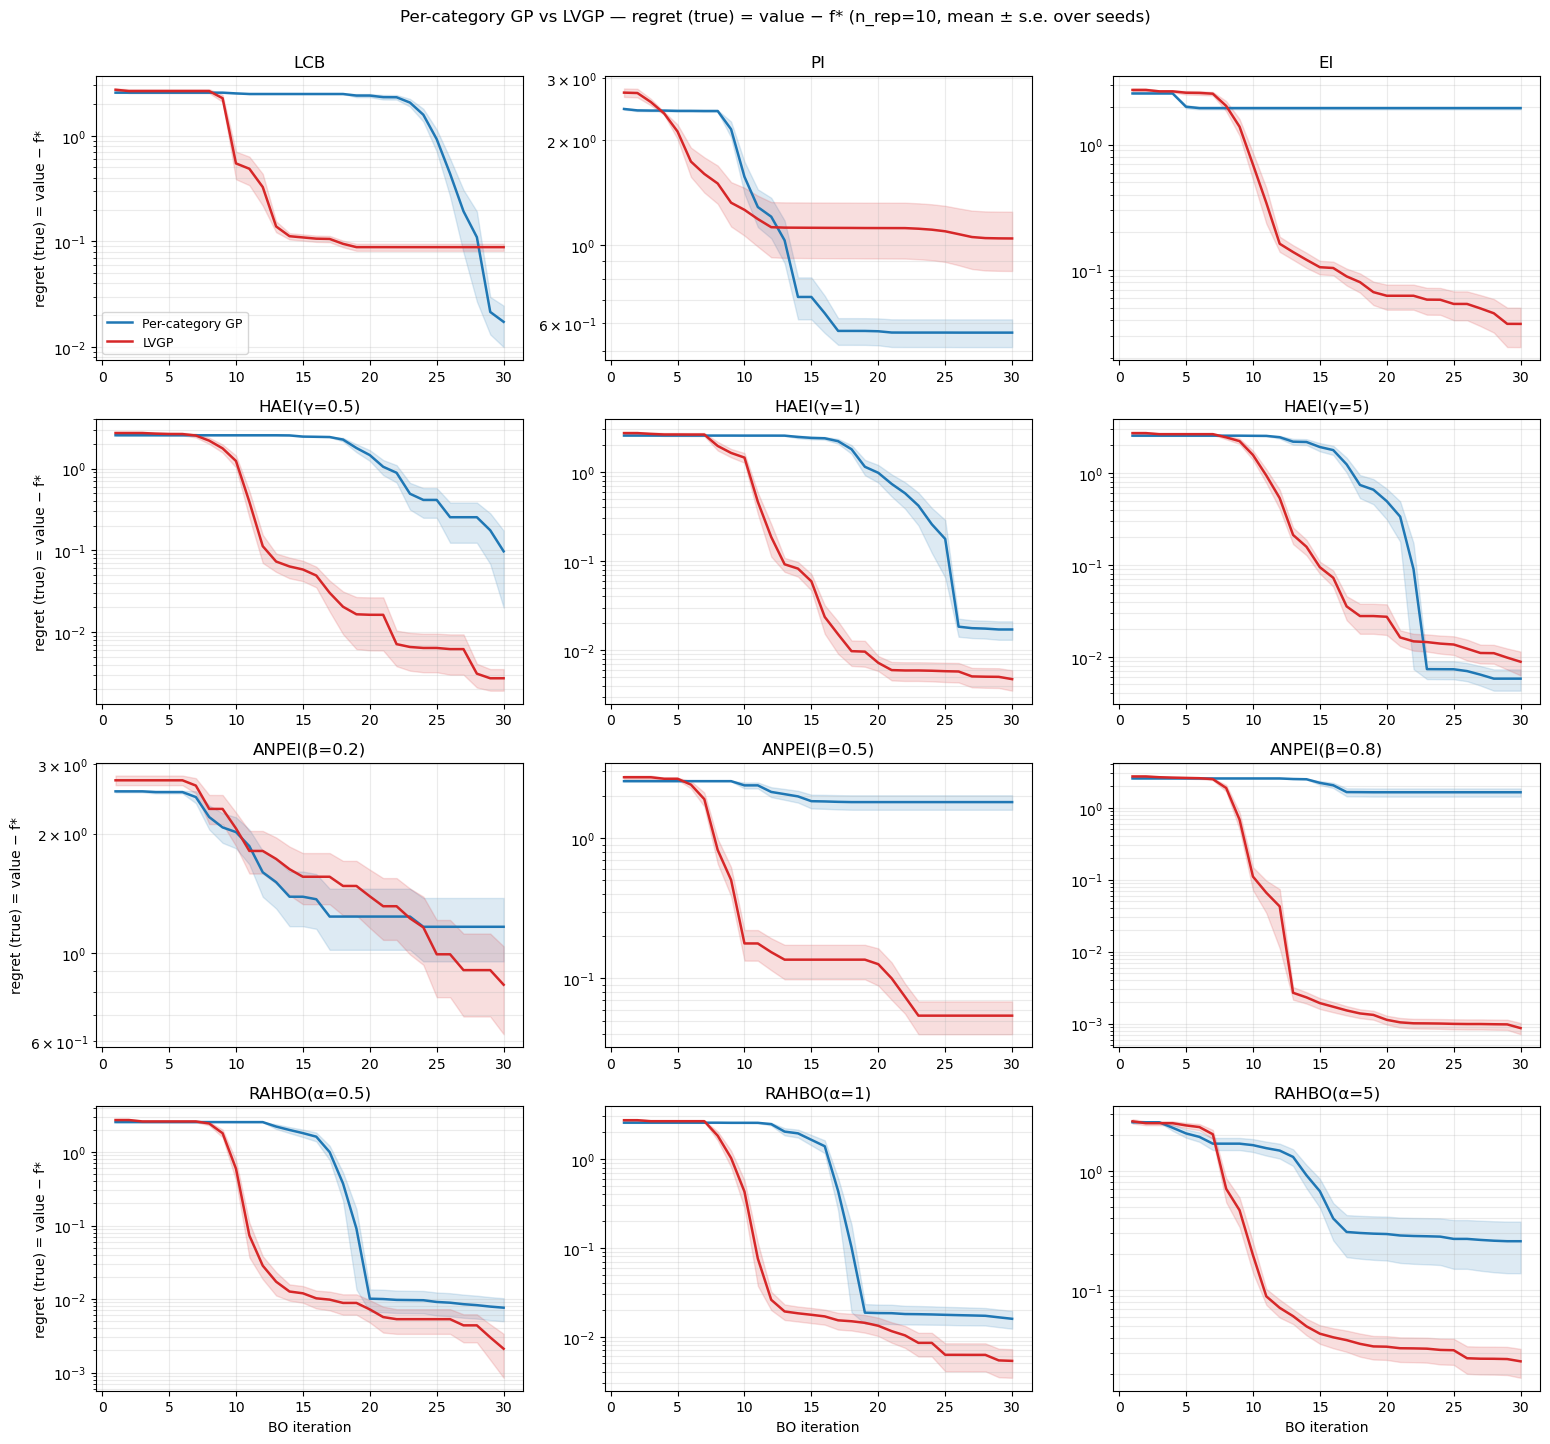

In [9]:
compare_studies(gp, lvgp, is_ground_truth=True, n_rep=10)

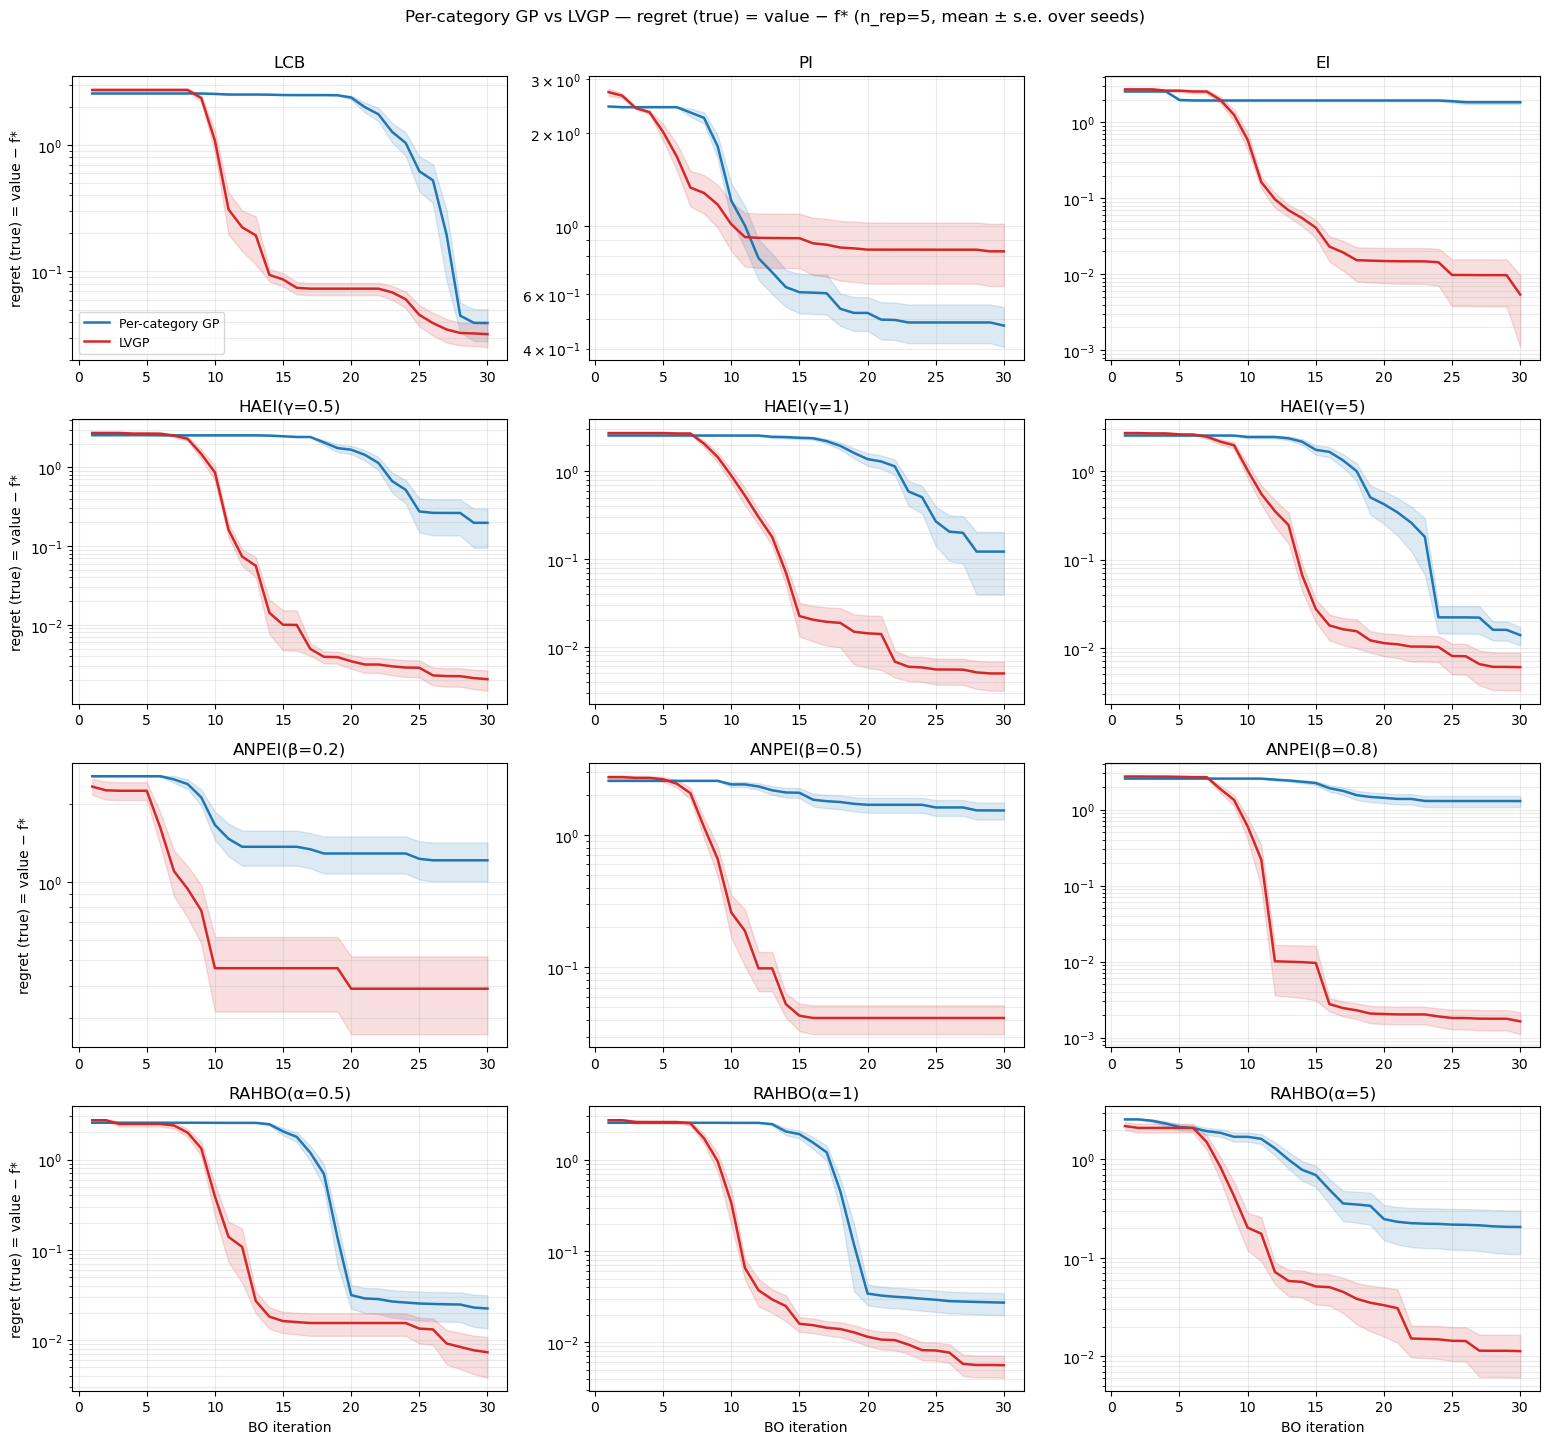

In [10]:
compare_studies(gp, lvgp, is_ground_truth=True, n_rep=5)    # noisier regime (fewer replicates)

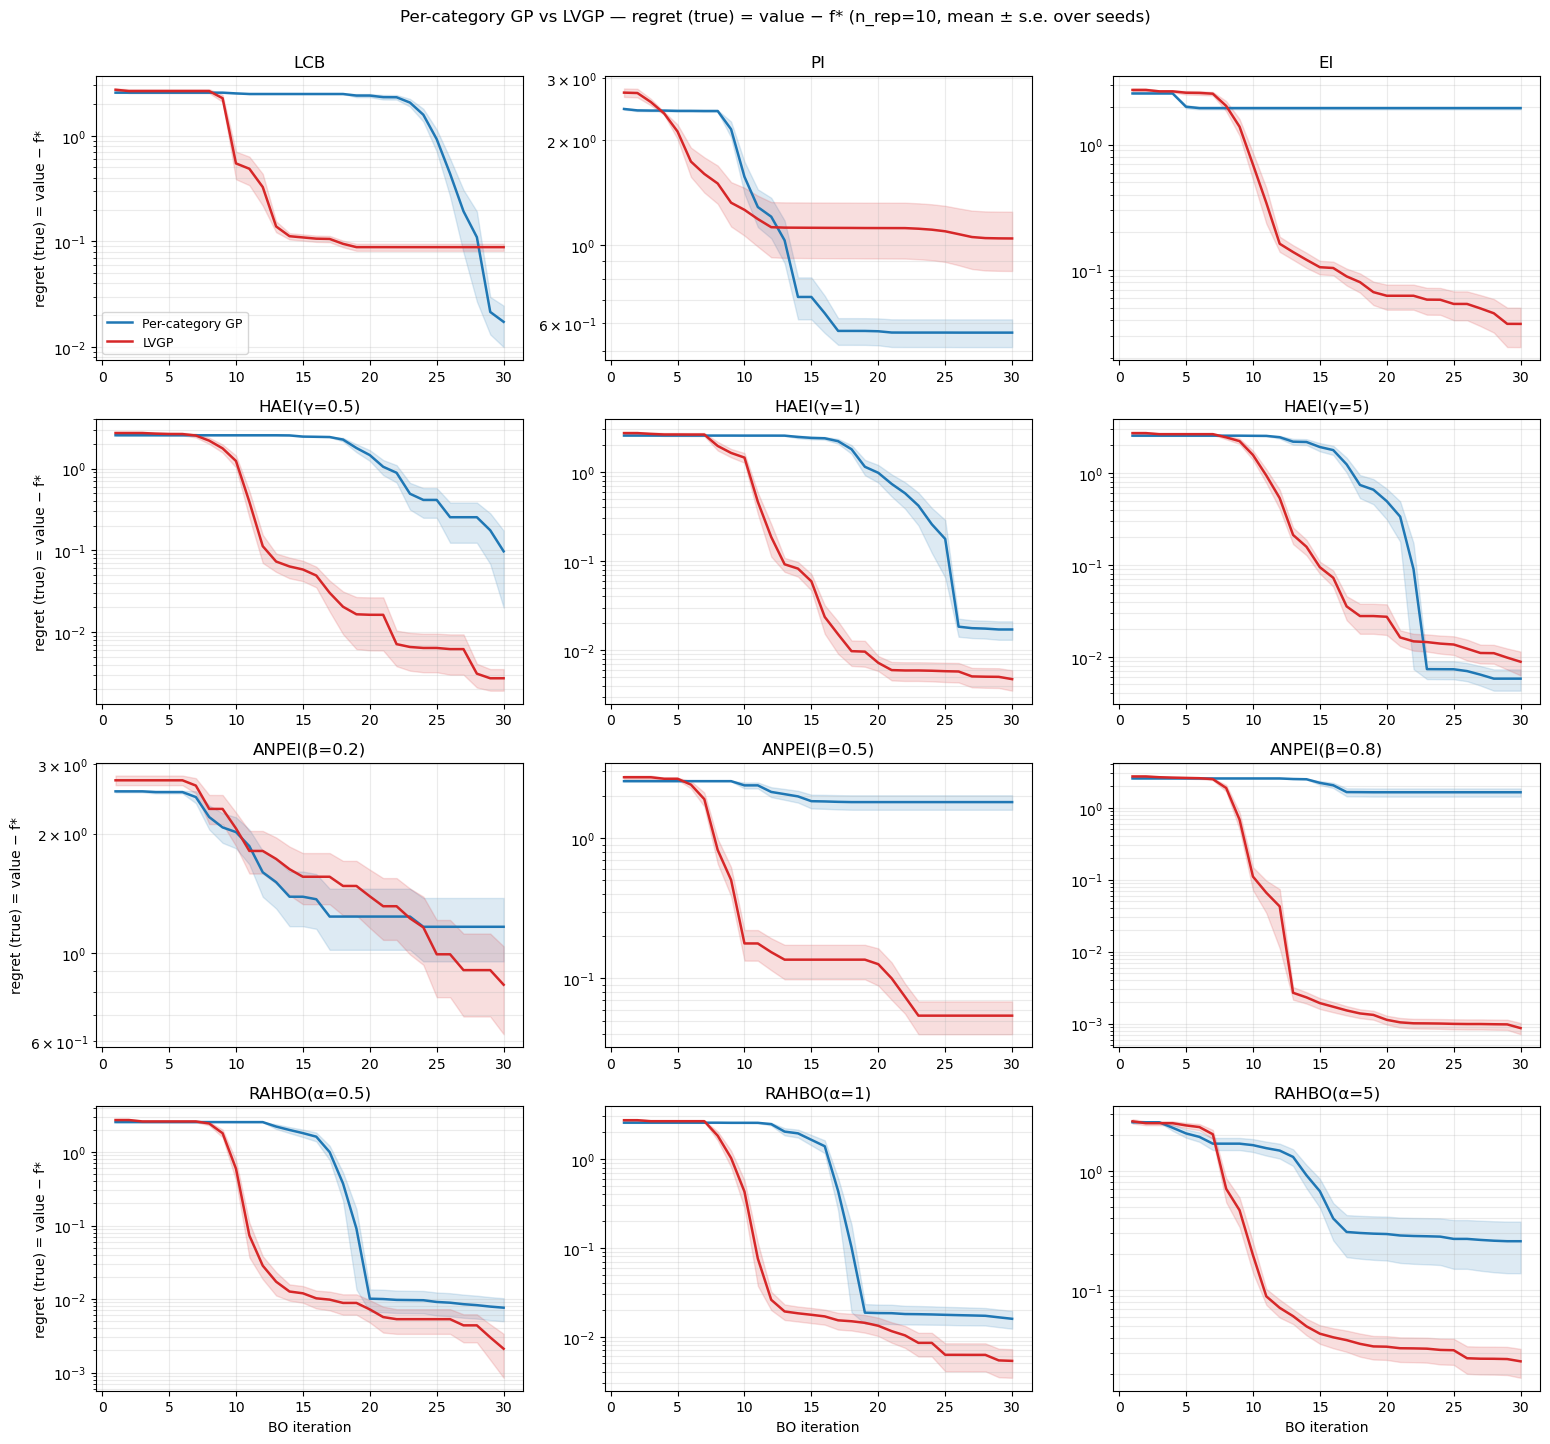

In [11]:
compare_studies(gp, lvgp, is_ground_truth=True, n_rep=10)        # noisy best-sample-mean convergence

## TODO (future step) — Method C: botorch *categorical* GP
The third arm is a single joint **`MixedSingleTaskGP` + `CategoricalKernel`** (one GP that
*models* the category, sharing across levels like LVGP but in botorch) — the "Method C"
prototype in `heterockedastic_new_inv/heterosk.ipynb` (cells 44–52). Not implemented here.

To add it later with **zero plotting changes**: build `study_v2_cat/` that runs the same sweep
with the joint categorical model and saves the **same `.npz` field schema**; then:

```python
# cat = StudyResults.load("../../study_v2_cat/results")
# compare_studies(gp,  cat, labels=("Per-category GP", "BoTorch categorical"), metric="true_regret")
# compare_studies(lvgp, cat, labels=("LVGP",          "BoTorch categorical"), metric="true_regret")
```


## Regenerate every figure in `plots/` in one call
Runs `save_all_plots.main()` — main + analysis + single_runs + comparison — so you don't call each plot by hand. Reads `results/`, never re-runs the optimization. (Backend stays inline; figures are saved to `plots/`, not shown here.)

In [12]:
import importlib, save_all_plots
importlib.reload(save_all_plots)   # pick up any edits
save_all_plots.main()              # writes plots/{main,analysis,single_runs,comparison}/

loaded 1080 runs
plots/main:
  saved plots/main/0_progress.png
  saved plots/main/0b_initial_doe.png
  saved plots/main/1_convergence_noisy.png
  saved plots/main/1b_convergence_true_log.png
  saved plots/main/1b_convergence_true_zoom.png
  saved plots/main/1c_x1_convergence_noisy.png
  saved plots/main/1c_x1_convergence_true.png
  saved plots/main/1d_x1_distribution_noisy.png
  saved plots/main/1d_x1_distribution_true.png
  saved plots/main/1e_x1_landing.png
  saved plots/main/2_input_space.png
  saved plots/main/2b_best_designs_noisy.png
  saved plots/main/2b_best_designs_true.png
  saved plots/main/3_level_histogram.png
  saved plots/main/4_objective_variance_noisy.png
  saved plots/main/4_objective_variance_true.png
  saved plots/main/5_final_boxplots_noisy.png
  saved plots/main/5_final_boxplots_true.png
  saved plots/main/6_best_per_category_noisy.png
  saved plots/main/6_best_per_category_true.png
plots/analysis:
  saved plots/analysis/A_simple_regret_noisy.png
  saved plots/ana